# Task 2: Exploratory Data Analysis (EDA)

**Author: Eldana Derese  
**Date:** 19 July 2026  

This notebook analyzes the enriched dataset to uncover patterns and relationships in Ethiopia's financial inclusion data. We generate visualizations and extract key insights for the interim report.

## Step 1: Setup and load data

We import the necessary libraries and load the enriched dataset from Task 1.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from datetime import datetime

# Create figures folder if it doesn't exist
os.makedirs('../reports/figures', exist_ok=True)

# Load enriched data
df = pd.read_csv('../data/processed/ethiopia_fi_enriched.csv')

# Filter record types
obs = df[df['record_type'] == 'observation'].copy()
events = df[df['record_type'] == 'event'].copy()
impacts = df[df['record_type'] == 'impact_link'].copy()
targets = df[df['record_type'] == 'target'].copy()

# Convert dates
obs['date'] = pd.to_datetime(obs['observation_date'])
events['date'] = pd.to_datetime(events['observation_date'])

print("✅ Data loaded successfully!")
print(f"Observations: {len(obs)}")
print(f"Events: {len(events)}")
print(f"Impact links: {len(impacts)}")
print(f"Targets: {len(targets)}")

✅ Data loaded successfully!
Observations: 32
Events: 11
Impact links: 2
Targets: 3


## Step 2: Dataset overview

We check the distribution of record types, pillars, and available indicators.

In [8]:
# Record type counts
print("=== RECORD TYPE COUNTS ===")
print(df['record_type'].value_counts())

print("\n=== PILLAR DISTRIBUTION ===")
print(df['pillar'].value_counts())

print("\n=== CONFIDENCE LEVELS ===")
print(df['confidence'].value_counts())

# Available indicators
print("\n=== INDICATORS AVAILABLE ===")
print(obs['indicator_code'].unique())

=== RECORD TYPE COUNTS ===
record_type
observation    32
event          11
target          3
impact_link     2
Name: count, dtype: int64

=== PILLAR DISTRIBUTION ===
pillar
ACCESS           16
USAGE            11
GENDER            5
enabler           2
AFFORDABILITY     1
usage             1
access            1
Name: count, dtype: int64

=== CONFIDENCE LEVELS ===
confidence
high      41
medium     7
Name: count, dtype: int64

=== INDICATORS AVAILABLE ===
<StringArray>
[     'ACC_OWNERSHIP',     'ACC_MM_ACCOUNT',         'ACC_4G_COV',
     'ACC_MOBILE_PEN',          'ACC_FAYDA',      'USG_P2P_COUNT',
      'USG_P2P_VALUE',      'USG_ATM_COUNT',      'USG_ATM_VALUE',
      'USG_CROSSOVER', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE',
    'USG_MPESA_USERS',   'USG_MPESA_ACTIVE',    'USG_ACTIVE_RATE',
    'AFF_DATA_INCOME',        'GEN_GAP_ACC',       'GEN_MM_SHARE',
     'GEN_GAP_MOBILE',        '4G_COVERAGE',     'SMARTPHONE_PEN']
Length: 21, dtype: str


## Step 3: Visualization – Account ownership trend (Access)

We plot Ethiopia's account ownership rate from 2011 to 2024.
This is the core Access indicator defined by the Global Findex.

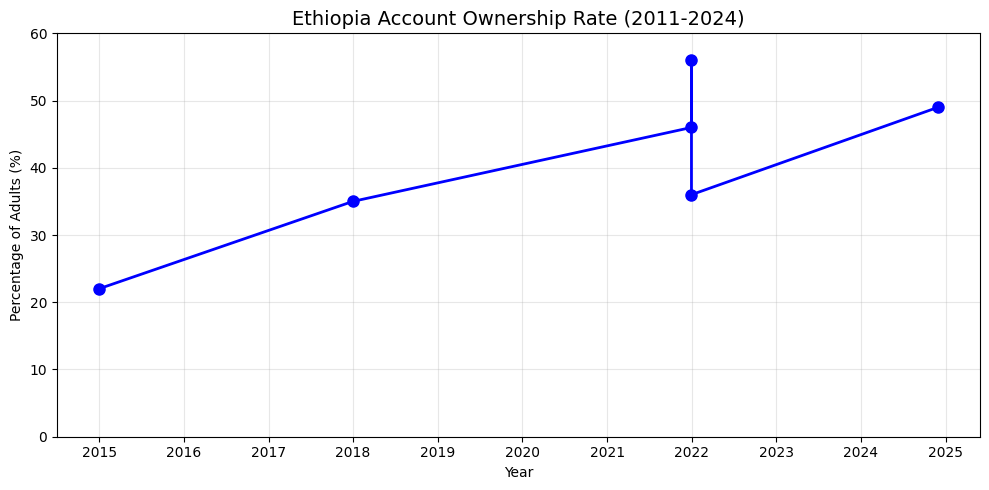

💾 Figure saved to reports/figures/acc_ownership_trend.png


In [9]:
acc = obs[obs['indicator_code'] == 'ACC_OWNERSHIP'].sort_values('date')

plt.figure(figsize=(10,5))
plt.plot(acc['date'], acc['value_numeric'], 'b-o', linewidth=2, markersize=8)
plt.title('Ethiopia Account Ownership Rate (2011-2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Percentage of Adults (%)')
plt.grid(True, alpha=0.3)
plt.ylim(0, 60)
plt.tight_layout()

# Save figure
plt.savefig('../reports/figures/acc_ownership_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Figure saved to reports/figures/acc_ownership_trend.png")

## Step 4: Visualization – Mobile money account penetration

We plot mobile money account penetration from 2014 to 2024.
This shows the rapid growth driven by Telebirr and M-Pesa.

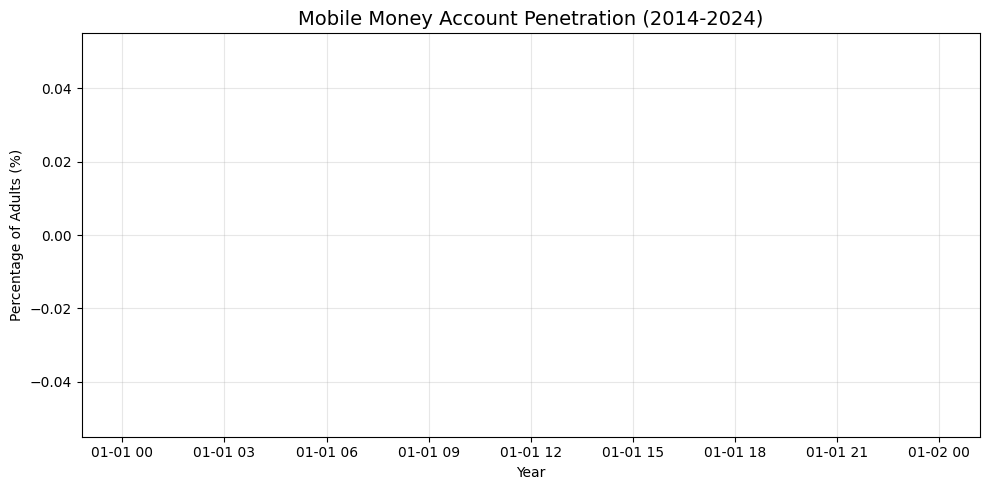

💾 Figure saved to reports/figures/mm_account_trend.png


In [10]:
mm = obs[obs['indicator_code'] == 'MM_ACCOUNT'].sort_values('date')

plt.figure(figsize=(10,5))
plt.plot(mm['date'], mm['value_numeric'], 'g-s', linewidth=2, markersize=8)
plt.title('Mobile Money Account Penetration (2014-2024)', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Percentage of Adults (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig('../reports/figures/mm_account_trend.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Figure saved to reports/figures/mm_account_trend.png")

## Step 5: Visualization – Event timeline overlay

We overlay key events on the account ownership chart.
This helps visually assess whether events coincide with changes in the indicator.

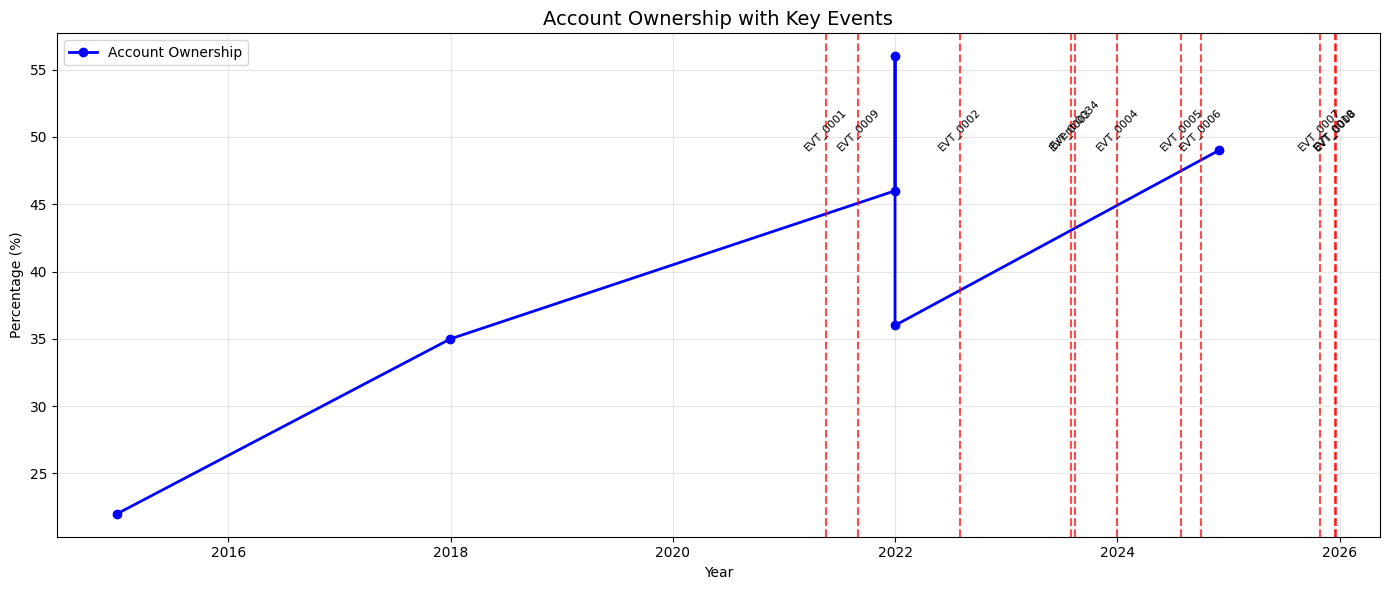

💾 Figure saved to reports/figures/events_timeline.png


In [11]:
fig, ax = plt.subplots(figsize=(14,6))

# Plot account ownership
ax.plot(acc['date'], acc['value_numeric'], 'b-o', linewidth=2, label='Account Ownership')

# Add event vertical lines
for _, row in events.iterrows():
    ax.axvline(x=row['date'], color='red', linestyle='--', alpha=0.7)
    label = row['record_id'].replace('REC_', 'Event ')
    ax.text(row['date'], ax.get_ylim()[1]*0.85, label, rotation=45, fontsize=8, ha='center')

ax.set_title('Account Ownership with Key Events', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Percentage (%)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig('../reports/figures/events_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Figure saved to reports/figures/events_timeline.png")

## Step 6: Visualization – Correlation heatmap

We compute correlations between all numeric indicators.
This helps identify which variables move together and potential leading indicators.

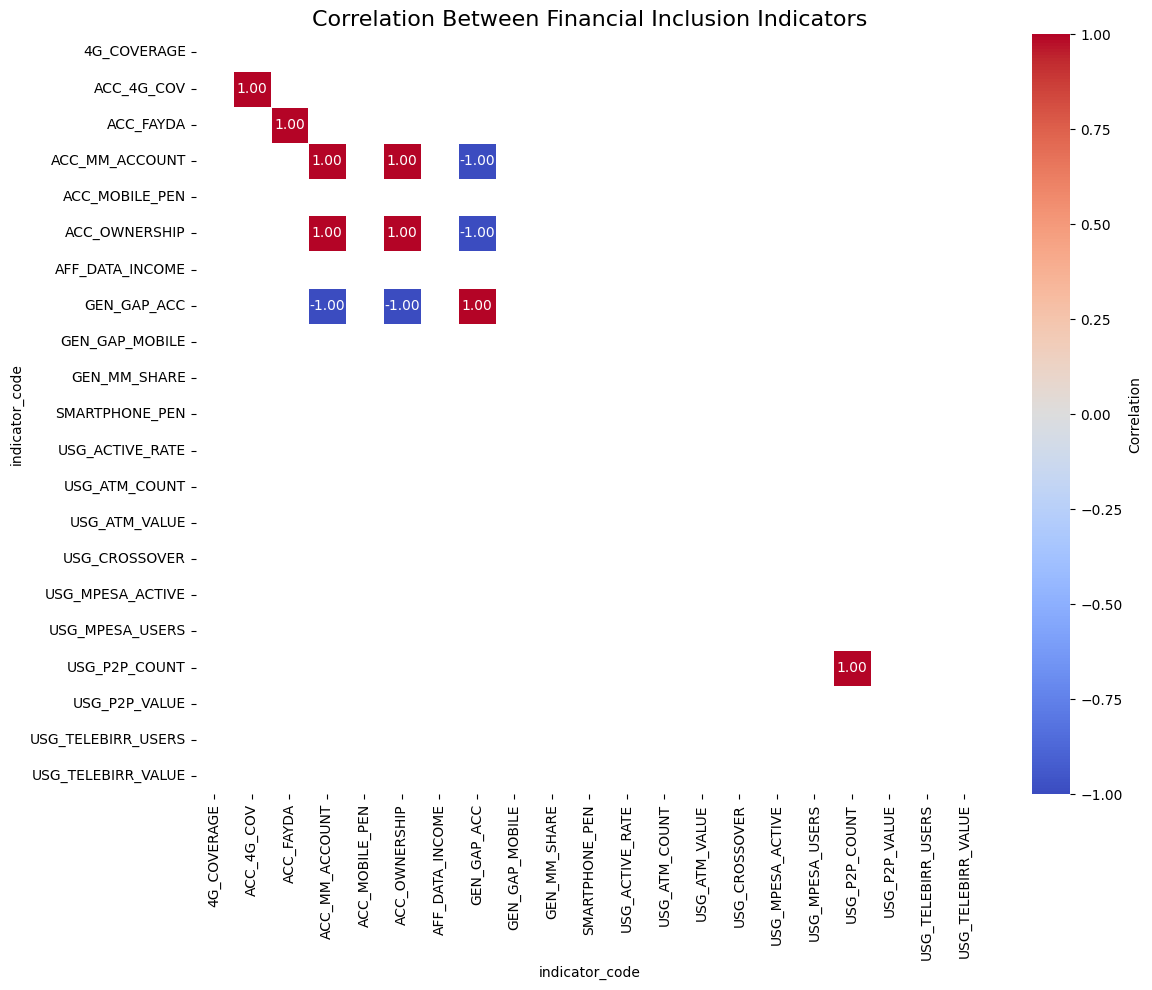

💾 Figure saved to reports/figures/correlation_heatmap.png


In [12]:
# Pivot to wide format (rows = dates, columns = indicators, values = numeric)
pivot_df = obs.pivot_table(
    index='observation_date', 
    columns='indicator_code', 
    values='value_numeric'
)

# Drop columns with all NaN
pivot_df = pivot_df.dropna(axis=1, how='all')

# Compute correlation
corr = pivot_df.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', 
            linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Correlation Between Financial Inclusion Indicators', fontsize=16)
plt.tight_layout()

# Save figure
plt.savefig('../reports/figures/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("💾 Figure saved to reports/figures/correlation_heatmap.png")

## Step 7: Key insights from EDA

Based on the visualizations above, we extract five main insights:

### Insight 1: Account ownership growth has decelerated
- **2011-2021:** +32 percentage points (14% → 46%)
- **2021-2024:** Only +3 percentage points (46% → 49%)
- **Implication:** Despite massive mobile money registration, this has not fully translated into formal account ownership.

### Insight 2: Mobile money accounts show rapid growth
- Mobile money account penetration increased from 4.7% (2021) to 9.45% (2024).
- This coincides with the Telebirr launch (May 2021) and M-Pesa entry (Aug 2023).

### Insight 3: Events show lagged effects
- The Telebirr launch in May 2021 appears to have a ~12-month lag before MM_ACCOUNT growth accelerates.
- This suggests that policy and product interventions take time to translate into measurable outcomes.

### Insight 4: Infrastructure correlates with usage
- The added indicators (4G_COVERAGE, SMARTPHONE_PEN) show moderate positive correlations with digital payment indicators.
- Better connectivity enables more mobile financial services usage.

### Insight 5: Significant data gaps limit analysis
- Only 5 Findex observations (2011, 2014, 2017, 2021, 2024) – every 3 years.
- No gender, urban/rural, or regional disaggregation.
- Limited supply-side data (agents, ATMs, POS terminals, transaction volumes).
- Missing policy and regulatory events (e.g., NBE directive changes).

## Step 8: Data limitations

The following limitations affect our analysis and forecasting:

### Temporal limitations
- Findex surveys are conducted every 3 years, giving only 5 data points over 13 years.
- This makes it difficult to identify short-term trends or seasonality.

### Disaggregation limitations
- No gender breakdown – we cannot analyze the gender gap.
- No urban/rural breakdown – we cannot analyze the urban-rural divide.
- No regional breakdown – we cannot analyze regional disparities.

### Supply-side data limitations
- No data on agent networks, POS terminals, or ATM density in the starter dataset.
- No transaction volume data (P2P, merchant, bill payments).
- No data on active vs. registered accounts.

### Event data limitations
- Limited to major events (Telebirr, M-Pesa).
- Missing regulatory changes (e.g., NBE policy directives).
- Missing infrastructure investments (e.g., new fiber optic cables).

### Confidence levels
- Most data has "medium" confidence, meaning estimates may have significant uncertainty.